# Carl von Ossietzky Universität Oldenburg - Mapping

In [1]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [3]:
client = bigquery.Client(project='subugoe-collaborative')

In [4]:
oal = client.query(f"""
                    SELECT 
                        CASE 
                            WHEN inst_id = 445 THEN 'Universitätsmedizin Oldenburg'
                            WHEN inst_id = 6612 THEN 'Universitätsmedizin Oldenburg'
                            WHEN inst_id = 316 THEN 'Universitätsmedizin Oldenburg'
                            WHEN inst_id = 315 THEN 'Universitätsmedizin Oldenburg'
                            WHEN inst_id = 5488 THEN 'Helmholtz-Institut für Funktionelle Marine Biodiversität'
                            WHEN inst_id = 4564 THEN 'Institute for Science Networking Oldenburg GmbH'
                            ELSE 'not assigned'
                        END AS fak_name,
                        'Carl von Ossietzky Universität Oldenburg' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, kb_inst.inst_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202601` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202601` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.inst_id IN (
                              99, -- 'Carl von Ossietzky Universität Oldenburg'
                              445, -- 'Evangelisches Krankenhaus Oldenburg'
                              6612, -- 'UMO - Universitätsmedizin Oldenburg'
                              316, -- 'Klinikum Oldenburg gGmbH'
                              315, -- 'Pius-Hospital Oldenburg'
                              5488, -- 'Helmholtz-Institut für Funktionelle Marine Biodiversität an der Universität Oldenburg (HIFMB)'
                              4564 -- Institute for Science Networking Oldenburg GmbH
                          )
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [5]:
oal.head()

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,Carl von Ossietzky Universität Oldenburg,"Group Digitalized Energy Systems, Carl von Oss...",https://openalex.org/W4206045184
1,not assigned,Carl von Ossietzky Universität Oldenburg,Institute for Chemistry and Biology of the Mar...,https://openalex.org/W4311843610
2,not assigned,Carl von Ossietzky Universität Oldenburg,Helmholtz Institute for Functional Marine Biod...,https://openalex.org/W4311843610
3,Helmholtz-Institut für Funktionelle Marine Bio...,Carl von Ossietzky Universität Oldenburg,Helmholtz Institute for Functional Marine Biod...,https://openalex.org/W4311843610
4,not assigned,Carl von Ossietzky Universität Oldenburg,"Klinik für Neurologie, Carl von Ossietzky Univ...",https://openalex.org/W4298138773


In [6]:
oal.replace({'Universitätsmedizin Oldenburg': 'Fakultät VI - Medizin und Gesundheitswissenschaften'}, inplace=True)

In [7]:
MAPPING_DICT = {
    'Bibliotheks- und Informationssystem (BIS)': ['informationssystem'],
    'Center für lebenslanges Lernen (C3L)': ['lifelong learning', 'center für lebenslanges lernen'],
    #'CMC - Center for Migration, Education and Cultural Studies': [],
    'COAST - Zentrum für Umwelt- und Nachhaltigkeitsforschung': ['sustainability research', 'coast-zentrum'],
    #'ecco-ecology + communication Unternehmensberatung GmbH': [],
    'Fakultät I - Bildungs- und Sozialwissenschaften': ['(department|institute) (for|of) social science', '(school|institute|faculty|department) of education(al)?', 
                                                        'educational science', 'special (education|needs)', 'lernforschung',
                                                        'rehabilitation', 'research on learning', 'pedagogy', 'schooling', 
                                                        '(open|political|continuing) (education|theory)', 'department i educational',
                                                        'sozialwissenschaft(liche|en)', '(?<!religions)(?<!wirtschafts)päd(a)?gogik', 'social sciences institute'
                                                       ],
    'Fakultät II - Informatik, Wirtschafts- und Rechtswissenschaften': ['(business|energy) (informati(on|cs)|application|administration)', 
                                                                        'applied artific(i)?al intelligence', 'information technology',
                                                                        'digitalized', '(department|fachbereich|media)( of| für)? (economics|informati(k|cs)|business)', 
                                                                        'comput(er|ing) science', 'offis', 'sustainable information', 'economic(s and)? law', 
                                                                        'resilience learning', 'vwl', 'marketing', 'safety-security',
                                                                        'interconnected systems', '(public|ecological) economics', 'wirtschaftspädagogik', 'micro(-)?robotics',
                                                                        'rechtswissenschaften', 'finance and banking', 'medieninformatik', 
                                                                        'software engineering', 'accounting', 'innovation', 'formale sprachen', 
                                                                        'informatics (department|education)', 'embedded hardware', 'computational intelligence', 
                                                                        'safety and explainability', 'betriebswirtschaft', 'chair of management'
                                                                       ],
    'Fakultät III - Sprach- und Kulturwissenschaften': ['(institut(e)?|department) (of|für) musi(k|c)', 'kulturwissenschaften',
                                                        'department of (german|dutch)', 'visuelle kultur', '(german|american|slavic|dutch) studies',
                                                        'musicology', 'linguistics', '(niederland|sla(w|v)|german)istik', 'slavic department', 
                                                        'speech and music lab'
                                                       ],
    'Fakultät IV - Human- und Gesellschaftswissenschaften': ['philosoph(ie|y)', 'department of history', 'religionspädagogik', 'institut für geschichte',
                                                             'so(z|c)iolog(ie|y)', 'historisches institut', 'school iv', 'institute of history',
                                                             'theolog(ie|y)', 'sportwissenschaft', 'fak. iv', 'sport(s)? science'
                                                            ],
    'Fakultät V - Mathematik und Naturwissenschaften': ['(icbm)', 'chemi(e|stry) (und|and) biolog(ie|y)', 'industrial chemistry',
                                                        '(ins(t)?(i)?tut(e)?|department|school) (of|f(ü|u|ue)?r|at|for) (ch(e)?mi(e|stry)|physi(k|cs)|biolog(ie|y))', 
                                                        'biodiversit', 'animal navigation', 'biologie und umweltwissenschaften',
                                                        '(environmental|natural) science', 'nanoscale', 'mathemati(k|cs|sches)', 
                                                        'dida(k|c)ti(k|cs) (der|of) (chemi(e|stry)|physi(k|cs))', '(geo|bio)diversity',
                                                        '(physics|chemistry) department', 'sustainable energy', '(landscape|aquatic) ecology', 'geology', 
                                                        '(angewandte|technische|applied|physical|theoretical|organische|marine) chemi(e|stry)', 
                                                        'chemical engineering', 'ecology of plants', 'theoretical physic', 'gewässerökologie',
                                                        'evolutionsbiologie', 'marine sensor(ik|s)', 'genomics', 'evolutionary biology', '(plant|functional) ecology',
                                                        '(chemistry|physics) education', 'soil sci.'
                                                       ],
    'Fakultät VI - Medizin und Gesundheitswissenschaften': ['neuro(science|surgery|log(ie|y)|imaging)', 'anatom(ie|y)', 'health(\s)?(service|science|care)', 
                                                            'department of psychology', 'microbiology', 'gastroenterologie', 'laboratory medicine',
                                                            'geriatric', 'dermatology', 'allergologie', 'human medicine', 'gyn(a)?ecology', 'ophthalmology',
                                                            'acoust(.|ics)', 'surgery', 'fa(c|k)ult(ät|y) (6|vi)', 'pulmonology',  'h(ä|e)matolog(ie|y)', 
                                                            'psychiatr(ie|y)', 'machine learning division', 'gastroenterology', 'urology',
                                                            '(medical|medizinischer) (k|c)ampus', 'hearing', 'versorgungsforschung', 'gesundheit',
                                                            'psycholog(ie|y)', 'geneti(k|cs)', 'biometr(ie|y)', 'oncology', 'medizinische (physik|informatik)', 
                                                            'toxicology', 'clinical diagnostics', 'public health', 'medizintechnik',
                                                            'ernährung und funktionalität', 'medical device', 'cardiology', 'big data in medicine',
                                                            'klinikum oldenburg', 'intensivmedizin', 'psychosomatik', 'pediatrics', 'pius', 'klinische chemie',
                                                            'ohrenheilkunde', 'psychological methods', 'signal processing', 'space environment',
                                                            'universit(y|äts)(\s)?(klinik|medi(c|z)in(e)?)', 'immunol(.|ogy)', 'ethics in medicine', 
                                                            'medical (phys(.|ics)|informatics|technolog|radiation)', 
                                                            'ethik in der medizin', 'anesthesiology', 'pädiatrie', 'psychosomatic', 'allgemeinmedizin',
                                                            'radiology', 'otorhinolaryngology', 'emergency', 'ambulante', 'pathologie',
                                                            'hospital', 'general practice', 'ai4health', 'oldenburg clinic'
                                                          ],
    'Forschungszentrum Neurosensorik': ['cent(re|er)( for| of)? neurosensory', 'forschungszentrum( für)? neurosensorik', 'ag ("|‘)(neuro)?sens'],
    'ForWind - Zentrum für Windenergieforschung': ['wind energy', 'forwind'],
    'Hochschulsport': ['sport(s)? cent(re|er)'],
    #'Institute for Science Networking Oldenburg GmbH': [],
    #'Oldenburger Fortbildungszentrum (OFZ)': [],
    #'Zentrum für interdisziplinäre Frauen- und Geschlechterforschung (ZFG)': [],
    #'Zentrum für Lehrkräftebildung - Didaktisches Zentrum (DIZ)': [],
    'Helmholtz-Institut für Funktionelle Marine Biodiversität': ['(hifmb)', 'helmholtz institute'] # selbst ergänzt
}

In [8]:
with open('./mapping_tables_fak/oldenburg.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT, f, ensure_ascii=False)

In [9]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [10]:
df_with_inst = oal.copy()

df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned', 'fak_name'] = \
           df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [11]:
df_with_inst

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,"Fakultät II - Informatik, Wirtschafts- und Rec...",Carl von Ossietzky Universität Oldenburg,"Group Digitalized Energy Systems, Carl von Oss...",https://openalex.org/W4206045184
1,Fakultät V - Mathematik und Naturwissenschaften,Carl von Ossietzky Universität Oldenburg,Institute for Chemistry and Biology of the Mar...,https://openalex.org/W4311843610
2,Fakultät V - Mathematik und Naturwissenschaften,Carl von Ossietzky Universität Oldenburg,Helmholtz Institute for Functional Marine Biod...,https://openalex.org/W4311843610
3,Helmholtz-Institut für Funktionelle Marine Bio...,Carl von Ossietzky Universität Oldenburg,Helmholtz Institute for Functional Marine Biod...,https://openalex.org/W4311843610
4,Fakultät VI - Medizin und Gesundheitswissensch...,Carl von Ossietzky Universität Oldenburg,"Klinik für Neurologie, Carl von Ossietzky Univ...",https://openalex.org/W4298138773
...,...,...,...,...
12794,None,Carl von Ossietzky Universität Oldenburg,Carl von Ossietzky University of Oldenburg,https://openalex.org/W4328008215
12795,None,Carl von Ossietzky Universität Oldenburg,University of Oldenburg (Carl von Ossietzky Un...,https://openalex.org/W4385154966
12796,Fakultät V - Mathematik und Naturwissenschaften,Carl von Ossietzky Universität Oldenburg,Institute of Biology and Environmental Science...,https://openalex.org/W4385154966
12797,Fakultät VI - Medizin und Gesundheitswissensch...,Carl von Ossietzky Universität Oldenburg,"Cardiology Research Group, Faculty VI Medicine...",https://openalex.org/W4366605424


In [12]:
df_with_inst[df_with_inst.fak_name.isnull()].raw_affiliation_string.unique()

array(['Universität Oldenburg, Carl-von-Ossietzky-Straße 11, 26129 Oldenburg, Germany,',
       'University of Oldenburg, Oldenburg, Germany',
       'University of Oldenburg',
       'Carl von Ossietzky University of Oldenburg, Germany',
       'Oldenburg University',
       'Carl Von Ossietzky Universitaet Oldenburg',
       'Carl von Ossietzky University of Oldenburg, Oldenburg, Ammerländer Heerstraße 114-118, 26129, Oldenburg, Germany',
       'Carl von Ossietzky Universität Oldenburg',
       'Carl von Ossietzky University of Oldenburg, Ammerländer Heerstr. 114-118, 26129, Oldenburg, Germany',
       'Carl Von Ossietzky University, Ammerländer Heerstraße 114-118, 26129, Oldenburg, Germany',
       'Carl von Ossietzky Universität Oldenburg, Germany',
       'University of Oldenburg (Carl von Ossietzky Universität Oldenburg, Ammerländer Heerstr. 114, D- 26129 Oldenburg - Germany)',
       'Carl von Ossietzky University of Oldenburg, Oldenburg, Germany',
       'University of Oldenbu

In [13]:
df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()

,fak_name,openalex_id
0,Bibliotheks- und Informationssystem (BIS),5
1,COAST - Zentrum für Umwelt- und Nachhaltigkeit...,13
2,Center für lebenslanges Lernen (C3L),4
3,Fakultät I - Bildungs- und Sozialwissenschaften,359
4,"Fakultät II - Informatik, Wirtschafts- und Rec...",624
5,Fakultät III - Sprach- und Kulturwissenschaften,119
6,Fakultät IV - Human- und Gesellschaftswissensc...,173
7,Fakultät V - Mathematik und Naturwissenschaften,4039
8,Fakultät VI - Medizin und Gesundheitswissensch...,4671
9,ForWind - Zentrum für Windenergieforschung,42


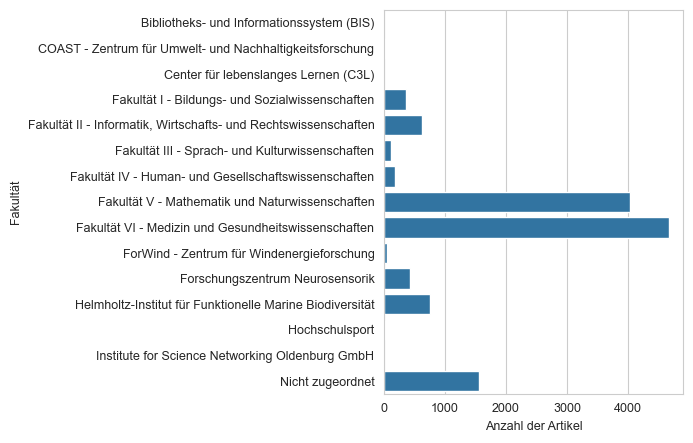

In [14]:
df_plot = df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='fak_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [15]:
df_plot[df_plot.fak_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.8781936088756934

In [179]:
MAPPING_DICT_DEPT = {
    'Fakultät I - Bildungs- und Sozialwissenschaften': {
        'Institut für Pädagogik': ['institut für päd(a)?gogik', '(department|institute) (of|for) (pedagogy|educational science)', 'educational psychology',
                                   'empirical research on learning', 'center for open education', 'lehr-lernforschung', 'institute of education'
                                  ],
        'Institut für Sonder- und Rehabilitatiospädagogik': ['special (educational )?(needs|education)', 'rehabilitation'],
        'Institut für Sozialwissenschaften': ['(institute|department) (for|of) social science', 'institut (für|fÃ¼r) sozialwissenschaften', 
                                              'political (theory|education)', 'social sciences institute', 'sozialwissenschaftliche theorie'
                                             ],
    },
    'Fakultät II - Informatik, Wirtschafts- und Rechtswissenschaften': {
        'Department für Informatik': ['informatics education', 'institute (for|of) information technology', '(media|business|energy) informatics', 
                                      'dep(t.|ar(t)?(e)?ment) (of( of)?|for|für) (comput(er|ing) science|informati(k|cs))', 'digitalized energy', 
                                      'medieninformatik', 'sustainable information',
                                      'distributed control', '(artific(i)?al|computational) intelligence', 'fachbereich informatik', 'formale sprachen',
                                      'offis', 'explainability', 'comput(er|ing) science department', 'business application', 'micro(-)?roboti(k|cs)',
                                      'resilience learning', 'software engineering', 'embedded'
                                     ],
        'Department für Wirtschafts- und Rechtswissenschaften': ['institute of economics', 'department of (business administration|economics)', 
                                                                 '(economic|environmental) law', 'wirtschaftspädagogik', 'rechtswissenschaften',
                                                                 'innovation', 'ecological economic', 'vwl', 'finance and banking', 'accounting',
                                                                 'marketing', 'betriebswirtschaft'
                                                                ],
    },
    'Fakultät III - Sprach- und Kulturwissenschaften': {
        'Institut für Anglistik und Amerikanistik': ['amerikanistik', 'anglistik', 'american studies'],
        'Institut für Germanistik': ['germanistik', 'german (studies|language)', 'department of german'],
        'Institut für Kunst und visuelle Kultur': ['visuelle kultur'],
        'Institut für Materielle Kultur': ['materielle kultur'],
        'Institut für Musik': ['musi(k|c)'],
        'Institut für Niederlandistik': ['niederlandistik', 'dutch studies', 'department of dutch'],
        'Institut für Slavistik': ['sla(w|v)istik', 'slavic (studies|department)'],
    },
    'Fakultät IV - Human- und Gesellschaftswissenschaften': {
        'Institut für Evangelische Theologie und Religionspädagogik': ['theolog(ie|y)'],
        'Institut für Geschichte': ['geschichte', 'history'],
        'Institut für Philosophie': ['philosoph(ie|y)'],
        'Institut für Sportwissenschaft': ['sport(s)? science', 'sportwissenschaft', 'so(z|c)iolog(ie|y)'],
    },
    'Fakultät V - Mathematik und Naturwissenschaften': {
        'Institut für Biologie und Umweltwissenschaften (IBU)': ['environmental (science|planning)', 'umweltwissenschaften', 'hydrolog(ie|y)', 'soil sci',
                                                                 '(landscape|plant|functional|aquatic) ecology', 'biodiversity', 
                                                                 'institut(e)? (für|for) biolog(ie|y)', 'neurosensor(ik|y)',
                                                                 'ecological genomics', 'evolutionsbiologie', 'gewässerökologie'
                                                                ],
        'Institut für Chemie (IfC)': ['(department|institut(e)?) (of|for|für) chemi(e|stry)', 'chemistry education', '(organische|technische|angewandte) chemie',
                                      'didaktik der chemie', '(industrial|applied|physical|theoretical) chemistry', 'chemistry department',
                                      'chemical engineering'
                                     ],
        'Institut für Chemie und Biologie des Meeres (ICBM)': ['marine', 'meeres', 'icbm'],
        'Institut für Mathematik (IFM)': ['(department|institut(e)?|school|inst.) (of|for|für|fÃ¼r|f(u)?r) mathemati(k|c)', 'mathematisches institut'],
        'Institut für Physik (IFP)': ['physi(k|cs)', 'nanoscale'],
    },
    'Fakultät VI - Medizin und Gesundheitswissenschaften': {
        'Department für Humanmedizin': ['human(\s)?medi(z|c)in', 'toxi(k|c)olog(ie|y)', 'mi(k|c)robiolog(ie|y)', 'neurosurgery', 'immunol(.|og(ie|y))',
                                        'ophthalmology', 'klinische chemie', 'dermatolog(ie|y)', 'pediatric', 'anatom(ie|y)', 'human genetics',
                                        'clinical chemistry', 'perinatal neurobiology', 'oncology', 'otorhinolaryngology', 'ohrenheilkunde',
                                        'intensivmedizin', 'urolog(ie|y)', 'gyn(a)?ecology', 'emergency', 'otolaryngology', 'genetics of childhood',
                                        'cardiology research group', '(cardiac|visceral|orthopaedic) surgery', 'department of cardiology',
                                        'anesthesiology', 'haematology', 'inflammation', 'internal medicine', 'humangenetik'
                                       ],
        'Department für Neurowissenschaften': ['neurolog(ie|y)', 'neuroscience', 'neurogenetics', 'neurosensory'],
        'Department für Psychologie': ['psycholog(ie|y)', 'psychotherap(ie|y)', 'psychiatry', 'psychological'],
        'Department für Versorgungsforschung': ['versorgungsforschung', 'health services research', 'ethi(k|cs)', 'epidemiolog(ie|y)',
                                                'assistance systems', 'assistenzsysteme', 'geriatri(e|c)', 'informatics', 'device technology',
                                                'allgemeinmedizin', 'ai4health', 'big data', 'assistive', 'medizinische informatik',
                                                'ernährung und funktionalität'
                                               ],
        'Department Medizinische Physik und Akustik': ['a(k|c)(o)?usti(k|c)', 'medizinische physik', 'hearing', 'radiation', 'signal processing',
                                                       'acoust.', 'machine learning', 'medical phys.'
                                                      ],
        'European Medical School Oldenburg-Groningen': ['european'],
        'Universitätsinstitut für Medizinische Genetik': ['medizinische genetik', 'medical genetics'],
        'Universitätsmedizin Oldenburg': ['universitätsmedizin', 'klinik', 'hospital', 'krankenhaus', 'gastroenterology',
                                          'radiolog(ie|y)', 'medical campus', 'university medicine', 'general practice', 'pius hosp'
                                         ], # selbst ergänzt
        'Neuroimaging Unit': ['neuroimaging unit'] # selbst ergänzt
    }
}

In [180]:
with open('./mapping_tables_dept/oldenburg.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT_DEPT, f, ensure_ascii=False)

In [181]:
def map_dept(address: str, faculty: str) -> Union[str, None]:
    if faculty in MAPPING_DICT_DEPT:
        for k, v in MAPPING_DICT_DEPT.get(faculty).items():
            pattern = re.compile(r'|'.join(v), re.IGNORECASE)
            res = bool(pattern.search(address))
            if res:
                return k
        return None
    else:
        return None

In [182]:
df_with_inst.loc[df_with_inst['fak_name'] == 'Fakultät VI - Medizin und Gesundheitswissenschaften', 'dept_name'] = \
    df_with_inst.loc[df_with_inst['fak_name'] == 'Fakultät VI - Medizin und Gesundheitswissenschaften']['raw_affiliation_string'].apply(map_dept, 
                                                                                                    faculty='Fakultät VI - Medizin und Gesundheitswissenschaften')

In [183]:
df_with_inst[(df_with_inst['fak_name'] == 'Fakultät VI - Medizin und Gesundheitswissenschaften') & df_with_inst['dept_name'].isnull()].raw_affiliation_string.unique()[:20]

array(['School of Medicine and Health Sciences Carl von Ossietzky University Oldenburg Oldenburg Germany',
       'School of Medicine and Health Sciences Carl von Ossietzky University Oldenburg  Oldenburg Germany',
       'School of Medicine and Health Services, Oldenburg University, Oldenburg, Germany',
       'School of Medicine and Health Sciences, Carl von Ossietzky University of Oldenburg, Oldenburg, Germany',
       'Department of Biomedical Sciences of Cells and Systems, University of Groningen, University Medical Center Groningen, Groningen, The Netherlands; School of Medicine and Health Sciences, Carl von Ossietzky University Oldenburg, Oldenburg, Germany',
       'School of Medicine and Health Sciences, Carl von Ossietzky University Oldenburg, Oldenburg, Germany',
       'School of Medicine and Health Sciences, University of Oldenburg, Oldenburg, Germany',
       'School of Medicine and Health Sciences, University of Oldenburg',
       'School of Medicine and Health Sciences,

In [184]:
df_with_inst[df_with_inst['fak_name'] == 'Fakultät VI - Medizin und Gesundheitswissenschaften'].groupby(['dept_name'], dropna=False)['openalex_id'].count().reset_index()

,dept_name,openalex_id
0,Department Medizinische Physik und Akustik,700
1,Department für Humanmedizin,1709
2,Department für Neurowissenschaften,208
3,Department für Psychologie,536
4,Department für Versorgungsforschung,680
5,European Medical School Oldenburg-Groningen,29
6,Neuroimaging Unit,6
7,Universitätsinstitut für Medizinische Genetik,34
8,Universitätsmedizin Oldenburg,647
9,NaN,122


In [185]:
df_with_inst[df_with_inst['fak_name'] == 'Fakultät VI - Medizin und Gesundheitswissenschaften']

,fak_name,parent_name,raw_affiliation_string,openalex_id,dept_name
4,Fakultät VI - Medizin und Gesundheitswissensch...,Carl von Ossietzky Universität Oldenburg,"Klinik für Neurologie, Carl von Ossietzky Univ...",https://openalex.org/W4298138773,Department für Humanmedizin
14,Fakultät VI - Medizin und Gesundheitswissensch...,Carl von Ossietzky Universität Oldenburg,"Department Human Medicine, Section Pharmacolog...",https://openalex.org/W4312196220,Department für Humanmedizin
16,Fakultät VI - Medizin und Gesundheitswissensch...,Carl von Ossietzky Universität Oldenburg,"Carl von Ossietzky Universitat Oldenburg, Univ...",https://openalex.org/W4207003598,Department für Humanmedizin
21,Fakultät VI - Medizin und Gesundheitswissensch...,Carl von Ossietzky Universität Oldenburg,"Klinikum Oldenburg, University Medical Center ...",https://openalex.org/W4229074710,Universitätsmedizin Oldenburg
22,Fakultät VI - Medizin und Gesundheitswissensch...,Carl von Ossietzky Universität Oldenburg,University Clinic for Medical Radiation Physic...,https://openalex.org/W4282828043,Department Medizinische Physik und Akustik
...,...,...,...,...,...
12781,Fakultät VI - Medizin und Gesundheitswissensch...,Carl von Ossietzky Universität Oldenburg,"Carl von Ossietzky Universität Oldenburg, Depa...",https://openalex.org/W3042612743,Department für Versorgungsforschung
12782,Fakultät VI - Medizin und Gesundheitswissensch...,Carl von Ossietzky Universität Oldenburg,"Klinikum Oldenburg, Klinik für Hals-, Nasen- u...",https://openalex.org/W3042479599,Universitätsmedizin Oldenburg
12789,Fakultät VI - Medizin und Gesundheitswissensch...,Carl von Ossietzky Universität Oldenburg,University Clinic for Medical Radiation Physic...,https://openalex.org/W3037838069,Department Medizinische Physik und Akustik
12790,Fakultät VI - Medizin und Gesundheitswissensch...,Carl von Ossietzky Universität Oldenburg,University Clinic for Medical Radiation Physic...,https://openalex.org/W3037838069,Department Medizinische Physik und Akustik
